# 06 - Dashboard de Predicciones

**Proyecto:** Pochoclo Predict

## Objetivo de este notebook

Cierre interactivo del proyecto: un mini-dashboard, dentro del propio
notebook, que permite inspeccionar predicciones individuales del **modelo
ganador** (guardado en `models/best_model.pkl` por `04_modelos_predictivos.ipynb`)
sobre peliculas del **test set** -es decir, peliculas que el modelo nunca vio
durante el entrenamiento ni la busqueda de hiperparametros-.

Con el boton "Nueva pelicula" se elige una pelicula al azar del test set y
se muestra:

- Titulo y datos relevantes (genero, director, año, duracion, presupuesto).
- Nota real vs. nota predicha, y la diferencia entre ambas.
- Un **medidor tipo tablero de auto** (aguja sobre un dial verde/amarillo/rojo,
  al estilo de un medidor de presion de aceite) que ubica el error de esa
  prediccion puntual, calibrado contra la distribucion real de errores del
  modelo en el test set (no con umbrales arbitrarios).
- Al lado del medidor, un **grafico acumulativo de predicho vs. real**
  (igual en espiritu al de la seccion 6 de NB04), que va sumando un punto
  por cada pelicula vista en la sesion -no se reinicia en cada click-,
  coloreado segun la zona del medidor en la que cayo esa prediccion.
- Una **metrica dinamica de la sesion**: a medida que se clickea el boton,
  se acumulan estadisticas (cantidad de peliculas vistas, error promedio,
  cuantas cayeron en cada zona del medidor) de todas las predicciones
  mostradas hasta el momento, no solo de la ultima.

El boton esta pensado para volver a generar otra pelicula al azar y repetir
la inspeccion las veces que se quiera.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import random

import ipywidgets as widgets
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle, Wedge
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split

from src import paths

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Carga del modelo ganador


In [2]:
modelo_guardado = joblib.load(paths.MODELS_DIR / "best_model.pkl")
modelo = modelo_guardado["modelo"]
nombre_modelo = modelo_guardado["nombre"]
columnas_features = modelo_guardado["features"]

print(f"Modelo ganador cargado: {nombre_modelo}")
print(f"Metricas en test (de NB04): {modelo_guardado['metricas_test']}")


Modelo ganador cargado: CatBoost
Metricas en test (de NB04): {'modelo': 'CatBoost', 'MAE': 0.6001637708352306, 'RMSE': 0.7607570253474715, 'R2': 0.31845648366857693, 'MAPE': 0.10440127063188263}


## 2. Reconstruccion del test set

Se recrea la **misma** particion train/test de `04_modelos_predictivos.ipynb`
(mismo `random_state`), para asegurar que el dashboard solo muestre
predicciones sobre peliculas que el modelo ganador no vio al entrenarse.
Despues se cruza por `id` con el dataset limpio de NB02 para recuperar
columnas descriptivas (titulo, director, sinopsis, etc.) que no forman parte
de la matriz de features.


In [3]:
feat = pd.read_csv(paths.FEATURES_CSV, encoding="utf-8-sig")
X = feat.drop(columns=["id", "nota_promedio"]).astype("float64")
y = feat["nota_promedio"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
ids_test = feat.loc[X_test.index, "id"]

peliculas = pd.read_csv(paths.EDA_CLEAN_CSV, encoding="utf-8-sig")
peliculas_test = peliculas[peliculas["id"].isin(ids_test)].set_index("id")

print(f"Peliculas en el test set disponibles para el dashboard: {len(peliculas_test)}")


Peliculas en el test set disponibles para el dashboard: 822


## 3. Predicciones sobre todo el test set y calibracion del semaforo

Se predice una sola vez sobre **todo** el test set (no en cada click del
boton, por eficiencia) y se calcula el error absoluto de cada prediccion.
Los umbrales del semaforo se calibran con los **percentiles 30 y 70** de esa
distribucion de errores: "buena" = el 30% de predicciones mas precisas de
este modelo, "mala" = el 30% menos preciso (y "regular" el 40% del medio),
en lugar de un numero arbitrario de puntos de diferencia.


Umbral 'buena' (<= P30): error absoluto <= 0.29 puntos
Umbral 'regular' (P31-P69): entre 0.29 y 0.78 puntos
Umbral 'mala' (>= P70): error absoluto > 0.78 puntos


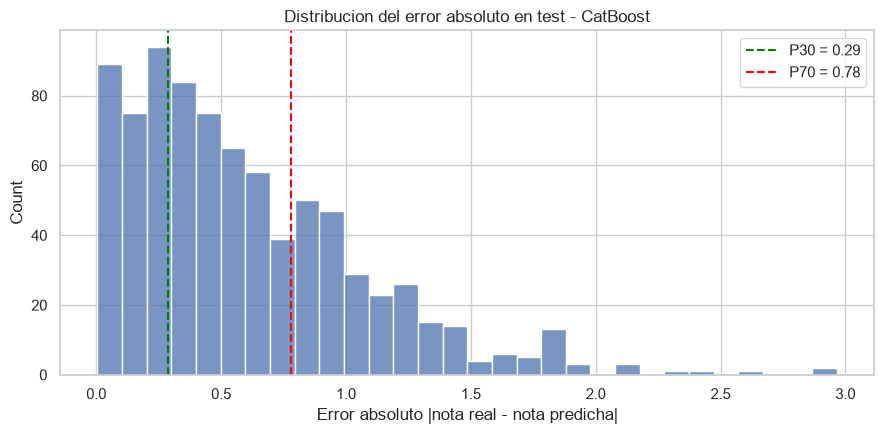

In [4]:
pred_test = modelo.predict(X_test[columnas_features])
errores_abs = np.abs(y_test.values - pred_test)

UMBRAL_BUENA, UMBRAL_REGULAR = np.percentile(errores_abs, [30, 70])

print(f"Umbral 'buena' (<= P30): error absoluto <= {UMBRAL_BUENA:.2f} puntos")
print(f"Umbral 'regular' (P31-P69): entre {UMBRAL_BUENA:.2f} y {UMBRAL_REGULAR:.2f} puntos")
print(f"Umbral 'mala' (>= P70): error absoluto > {UMBRAL_REGULAR:.2f} puntos")

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(errores_abs, bins=30, ax=ax)
ax.axvline(UMBRAL_BUENA, color="green", linestyle="--", label=f"P30 = {UMBRAL_BUENA:.2f}")
ax.axvline(UMBRAL_REGULAR, color="red", linestyle="--", label=f"P70 = {UMBRAL_REGULAR:.2f}")
ax.set_xlabel("Error absoluto |nota real - nota predicha|")
ax.set_title(f"Distribucion del error absoluto en test - {nombre_modelo}")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Dashboard interactivo

Disposicion del panel de cada pelicula:

- Arriba: poster, titulo, datos de la pelicula y sinopsis.
- Debajo de la sinopsis, a la izquierda: nota real / nota predicha /
  diferencia, y debajo el **medidor** (dial de 180° tipo medidor de aceite,
  con tres zonas segun los umbrales P30/P70 de la seccion anterior y una
  aguja en la posicion exacta del error absoluto). La escala del dial se
  fija en 1.6x el umbral "mala" (o el error mas grande del test set, el que
  sea mayor), para que sirva de referencia comun entre peliculas.
- A la derecha, ocupando el alto de la tabla + el medidor: el grafico de
  **predicho vs. real acumulado de la sesion** (mismo espiritu que el de la
  seccion 6 de NB04, pero construido en vivo): cada click agrega un punto,
  coloreado segun la zona del medidor en la que cayo esa prediccion. Los
  ejes cubren siempre el rango completo de notas del test set, para que la
  escala no cambie de un click al otro.
- Al pie, la metrica acumulada de la sesion.

El panel es un widget `HTML` cuyo contenido se reemplaza en cada click, en
lugar de capturar salidas con un widget `Output`: algunos front-ends (como
los notebooks de VS Code) muestran dos veces lo que se captura con `Output`
durante la ejecucion de la celda.


In [5]:
import base64
import io
import json
from html import escape

from src.tmdb_client import TMDBClient

ESCALA_MAXIMA_DIAL = max(UMBRAL_REGULAR * 1.6, errores_abs.max())
COLOR_POR_ZONA = {"VERDE": "#2e7d32", "AMARILLO": "#f9a825", "ROJO": "#c62828"}

# Alturas en pixeles del bloque inferior: el scatter mide lo mismo que la tabla
# de notas + el medidor, asi su eje x termina a la altura en que termina el dial.
ALTO_FILA_TABLA = 30
ALTO_MEDIDOR = 170
SEPARACION = 8
ALTO_SCATTER = 3 * ALTO_FILA_TABLA + SEPARACION + ALTO_MEDIDOR

# Anchos fijos de la tarjeta y de la columna izquierda (tabla + medidor): el
# scatter se dibuja con el ancho exacto que sobra, para llenar la derecha.
ANCHO_TARJETA = 820
ANCHO_IZQUIERDA = 290
GAP_COLUMNAS = 24
ANCHO_SCATTER = ANCHO_TARJETA - 2 * 16 - 2 - ANCHO_IZQUIERDA - GAP_COLUMNAS  # padding y borde de la tarjeta


def semaforo(error_abs):
    if error_abs <= UMBRAL_BUENA:
        return COLOR_POR_ZONA["VERDE"], "VERDE - prediccion buena"
    elif error_abs <= UMBRAL_REGULAR:
        return COLOR_POR_ZONA["AMARILLO"], "AMARILLO - prediccion regular"
    else:
        return COLOR_POR_ZONA["ROJO"], "ROJO - prediccion mala"


def formatear_moneda(valor):
    return f"USD {valor:,.0f}" if pd.notna(valor) and valor > 0 else "Sin dato"


def angulo_para_error(error_abs):
    # Mapea un error absoluto a un angulo en grados sobre el dial (180=izquierda/0, 0=derecha/maximo).
    fraccion = min(error_abs, ESCALA_MAXIMA_DIAL) / ESCALA_MAXIMA_DIAL
    return 180 - 180 * fraccion


def figura_a_base64(fig, recortar=True):
    buffer = io.BytesIO()
    if recortar:
        fig.savefig(buffer, format="png", dpi=200, bbox_inches="tight", pad_inches=0.03)
    else:
        fig.savefig(buffer, format="png", dpi=200)
    plt.close(fig)
    return base64.b64encode(buffer.getvalue()).decode("ascii")


def medidor_base64(error_abs):
    fig, ax = plt.subplots(figsize=(3.0, 1.9))
    zonas = [(0, UMBRAL_BUENA, COLOR_POR_ZONA["VERDE"]), (UMBRAL_BUENA, UMBRAL_REGULAR, COLOR_POR_ZONA["AMARILLO"]),
             (UMBRAL_REGULAR, ESCALA_MAXIMA_DIAL, COLOR_POR_ZONA["ROJO"])]
    for inicio, fin, color in zonas:
        ax.add_patch(Wedge((0, 0), 1.0, angulo_para_error(fin), angulo_para_error(inicio),
                            width=0.35, facecolor=color, edgecolor="white"))

    angulo_rad = np.radians(angulo_para_error(error_abs))
    ax.plot([0, 0.78 * np.cos(angulo_rad)], [0, 0.78 * np.sin(angulo_rad)],
            color="#222", linewidth=3, solid_capstyle="round", zorder=5)
    ax.add_patch(Circle((0, 0), 0.06, color="#222", zorder=6))

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"Error absoluto: {error_abs:.2f}", fontsize=9)
    return figura_a_base64(fig)


def scatter_base64(historial_df):
    # Tamaño exacto en pixeles de pantalla (100 px por pulgada, a dpi=200 para que se vea nitido).
    fig, ax = plt.subplots(figsize=(ANCHO_SCATTER / 100, ALTO_SCATTER / 100))
    for clasif, color in COLOR_POR_ZONA.items():
        sub = historial_df[historial_df["clasificacion"] == clasif]
        if len(sub):
            ax.scatter(sub["nota_real"], sub["nota_predicha"], color=color, alpha=0.85,
                       s=28, edgecolor="white", linewidth=0.5, label=clasif.capitalize())

    # Rango fijo al de las notas del test set (ampliado si algun punto se sale):
    # con pocos puntos, acotar la escala solo a ellos deja el grafico "pegado".
    extremos = [
        min(y_test.min(), historial_df["nota_real"].min(), historial_df["nota_predicha"].min()) - 0.3,
        max(y_test.max(), historial_df["nota_real"].max(), historial_df["nota_predicha"].max()) + 0.3,
    ]
    ax.plot(extremos, extremos, color="#999", linestyle="--", linewidth=1, label="Prediccion perfecta")
    ax.set_xlim(extremos)
    ax.set_ylim(extremos)
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    ax.tick_params(labelsize=7)
    ax.set_xlabel("Nota real", fontsize=8)
    ax.set_ylabel("Nota predicha", fontsize=8)
    ax.set_title(f"Predicho vs. real - sesion ({len(historial_df)})", fontsize=8.5)
    ax.legend(fontsize=6.5, loc="upper left")
    fig.tight_layout(pad=0.4)
    return figura_a_base64(fig, recortar=False)


historial_sesion = []  # se acumula con cada click, para el scatter y la metrica dinamica


def construir_html_pelicula(movie_id):
    fila_meta = peliculas_test.loc[movie_id]
    idx_feat = ids_test[ids_test == movie_id].index[0]

    nota_real = float(y_test.loc[idx_feat])
    nota_predicha = float(modelo.predict(X_test.loc[[idx_feat], columnas_features])[0])
    diferencia = nota_predicha - nota_real
    _, etiqueta_semaforo = semaforo(abs(diferencia))

    historial_sesion.append({
        "id": movie_id, "titulo": fila_meta["titulo"], "nota_real": nota_real,
        "nota_predicha": nota_predicha, "error_abs": abs(diferencia),
        "clasificacion": etiqueta_semaforo.split(" - ")[0],
    })
    historial_df = pd.DataFrame(historial_sesion)

    sinopsis = escape(fila_meta["sinopsis_es"] or "")
    reparto = json.loads(fila_meta["reparto_principal"])[:3] if isinstance(fila_meta["reparto_principal"], str) else []
    linea_reparto = f" · Reparto: {escape(', '.join(reparto))}" if reparto else ""

    poster_path = fila_meta.get("poster_path")
    url_poster = TMDBClient.poster_url(poster_path, size="w185") if pd.notna(poster_path) else None
    poster_html = (f'<img src="{url_poster}" style="width:110px; border-radius:6px; flex:0 0 auto;">'
                   if url_poster else "")

    img_medidor = medidor_base64(abs(diferencia))
    img_scatter = scatter_base64(historial_df)

    conteo = historial_df["clasificacion"].value_counts()
    sufijo_plural = "s" if len(historial_df) != 1 else ""
    estilo_celda = f"padding:0 16px 0 0; height:{ALTO_FILA_TABLA}px; line-height:{ALTO_FILA_TABLA}px;"
    estilo_valor = f"padding:0; height:{ALTO_FILA_TABLA}px; line-height:{ALTO_FILA_TABLA}px; text-align:right;"

    return f'''
    <div style="border:1px solid #ddd; border-radius:10px; padding:16px; width:{ANCHO_TARJETA}px; max-width:100%; box-sizing:border-box;
                font-family:sans-serif; line-height:1.35; white-space:normal;">
      <div style="display:flex; gap:16px; align-items:flex-start;">
        {poster_html}
        <div style="flex:1 1 auto;">
          <h2 style="margin:0 0 4px 0;">{escape(str(fila_meta["titulo"]))}</h2>
          <p style="margin:0 0 10px 0; color:#666;">
            {fila_meta["genero_principal"]} · {int(fila_meta["anio_estreno"])} ·
            {int(fila_meta["duracion_min"])} min · Dir.: {escape(str(fila_meta["director"]))}{linea_reparto}
          </p>
          <p style="margin:0 0 10px 0;">Presupuesto: {formatear_moneda(fila_meta["presupuesto"])}</p>
          <p style="margin:0; font-style:italic; color:#444;">{sinopsis}</p>
        </div>
      </div>

      <div style="display:flex; gap:{GAP_COLUMNAS}px; align-items:flex-start; margin-top:14px;">
        <div style="flex:0 0 {ANCHO_IZQUIERDA}px;">
          <table style="border-collapse:collapse;">
            <tr><td style="{estilo_celda}"><b>Nota real</b></td><td style="{estilo_valor}">{nota_real:.2f}</td></tr>
            <tr><td style="{estilo_celda}"><b>Nota predicha</b> ({nombre_modelo})</td><td style="{estilo_valor}">{nota_predicha:.2f}</td></tr>
            <tr><td style="{estilo_celda}"><b>Diferencia</b></td><td style="{estilo_valor}">{diferencia:+.2f}</td></tr>
          </table>
          <img src="data:image/png;base64,{img_medidor}" style="height:{ALTO_MEDIDOR}px; display:block; margin-top:{SEPARACION}px;">
        </div>
        <div style="flex:1 1 auto; min-width:0;">
          <img src="data:image/png;base64,{img_scatter}" style="width:{ANCHO_SCATTER}px; height:{ALTO_SCATTER}px; max-width:100%; object-fit:contain; object-position:left top; display:block;">
        </div>
      </div>

      <div style="border:1px dashed #aaa; border-radius:8px; padding:10px 14px; margin-top:14px;">
        <b>Metrica de la sesion</b> (acumulada, {len(historial_df)} pelicula{sufijo_plural} vista{sufijo_plural})
        <table style="border-collapse:collapse; margin-top:6px;">
          <tr>
            <td style="padding:2px 12px 2px 0;">Error absoluto promedio</td>
            <td style="padding:2px 12px;">{historial_df["error_abs"].mean():.2f}</td>
          </tr>
          <tr>
            <td style="padding:2px 12px 2px 0;">Verdes / Amarillas / Rojas</td>
            <td style="padding:2px 12px;">{conteo.get("VERDE", 0)} / {conteo.get("AMARILLO", 0)} / {conteo.get("ROJO", 0)}</td>
          </tr>
        </table>
      </div>
    </div>
    '''


panel = widgets.HTML(layout=widgets.Layout(width="100%"))
boton = widgets.Button(description="Nueva pelicula", button_style="primary", icon="refresh")


def al_hacer_click(_boton):
    movie_id = random.choice(ids_test.tolist())
    panel.value = construir_html_pelicula(movie_id)


boton.on_click(al_hacer_click)
al_hacer_click(None)  # primer ejemplo, ya cargado al mostrar el widget
display(widgets.VBox([boton, panel]))


## 5. Conclusiones

- El dashboard confirma, pelicula a pelicula, lo que ya mostraban las
  metricas agregadas de NB04: la mayoria de las predicciones caen en la zona
  verde/amarilla del medidor, con una minoria de casos en zona roja
  -tipicamente peliculas atipicas para su genero/elenco/presupuesto
  habitual-. La metrica acumulada de la sesion deja ver esa proporcion de
  forma directa a medida que se prueban mas peliculas.
- Al estar calibrado con los percentiles del propio test set, el medidor es
  una referencia *relativa al modelo actual*: si en una iteracion futura del
  proyecto se entrena un modelo mejor (menor error general), los mismos
  umbrales se recalculan solos y exigen mas precision para llegar a la zona
  verde.
